# Convulational Neural Network for CIFAR10 Dataset

## Overview

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

Here are the classes in the dataset, as well as 10 random images from each:
- airplane
- automobile				
- bird										
- cat										
- deer										
- dog										
- frog										
- horse										
- ship										
- truck

The classes are completely mutually exclusive. There is no overlap between automobiles and trucks. "Automobile" includes sedans, SUVs, things of that sort. "Truck" includes only big trucks. Neither includes pickup trucks. We can use it to demonstrate how a CNN can learn to recognize objects in images:

1. Task & dataset
2. Data cleaning & preparation
3. Exploratory Data Analysis (EDA)
4. Train/validation/test split
5. Model training (forward pass, backprop, optimiser)
6. Evaluation metrics & loss curves
7. Error analysis
8. Pros, cons & real-world examples

## Setup and Imports

In [2]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. Load the CIFAR10 dataset

The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.

In [59]:
data_dir = Path("data")

def load_batch(filename):
    with open(data_dir / filename, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.asarray(batch[b"labels"]).ravel()
    return images, labels

train_batches = [load_batch(f"data_batch_{i}") for i in range(1, 6)]
X_train = np.concatenate([x for x, _ in train_batches])
y_train = np.concatenate([y for _, y in train_batches])
X_test, y_test = load_batch("test_batch")

print('X_train shape:', X_train.shape)  # (60000, 28, 28)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print('Pixel value range:', X_train.min(), '-', X_train.max())
print('Unique labels:', np.unique(y_train))

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
X_test  shape: (10000, 32, 32, 3)
y_test  shape: (10000,)
Pixel value range: 0 - 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


- The dataset loads cleanly as **50,000 training** and **10,000 test** images, each 32 x 32 pixels with 3 colour channels.
- The raw pixels are whole numbers from **0 to 255**, which is why the next step scales them down.
- Labels come through as plain numbers 0-9. The following cell attaches the class names to them.

In [60]:
class_names = [
    "Airplane", "Automobile", "Bird", 
    "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"
]
print(list(zip(np.unique(y_train), class_names)))

[(np.int64(0), 'Airplane'), (np.int64(1), 'Automobile'), (np.int64(2), 'Bird'), (np.int64(3), 'Cat'), (np.int64(4), 'Deer'), (np.int64(5), 'Dog'), (np.int64(6), 'Frog'), (np.int64(7), 'Horse'), (np.int64(8), 'Ship'), (np.int64(9), 'Truck')]


## 2. Data Cleaning and Preprocessing

In [61]:
# check for missing values (Nan or out of range values) -sanity check
print('Nan in X_train: ', np.isnan(X_train).any())
print('Nan in y_train: ', np.isnan(y_train).any())

Nan in X_train:  False
Nan in y_train:  False


- No missing values anywhere, in either the images or the labels.
- That means there is nothing to impute and no row to drop, so preprocessing comes down to a single step: scaling the pixels.

In [ ]:
# normalize pixel values to be between 0 and 1 for stable gradient descent
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print('X_train shape after prep:', X_train.shape)
print('X_test shape after prep :', X_test.shape)
print('New pixel range:', X_train.min(), '-', X_train.max())

X_train shape after prep: (50000, 32, 32, 3)
X_test shape after prep : (10000, 32, 32, 3)
New pixel range: 0.0 - 1.0


- Dividing by 255 moves every pixel into the 0-1 range.
- Small, evenly-scaled inputs keep the gradients small, which makes training stable and converges faster.
- The arrays are now `float32` rather than `uint8`, which is what the network expects and uses much less memory.

## 3. Exploratory Data Analysis

In [63]:
train_counts = pd.Series(np.asarray(y_train).ravel()).value_counts()
test_counts = pd.Series(np.asarray(y_test).ravel()).value_counts()

balance_df = pd.DataFrame({
    "Class": class_names,
    "Train": train_counts.reindex(range(len(class_names)), fill_value=0).to_numpy(),
    "Test": test_counts.reindex(range(len(class_names)), fill_value=0).to_numpy()
})
balance_df

,Class,Train,Test
0,Airplane,5000,1000
1,Automobile,5000,1000
2,Bird,5000,1000
3,Cat,5000,1000
4,Deer,5000,1000
5,Dog,5000,1000
6,Frog,5000,1000
7,Horse,5000,1000
8,Ship,5000,1000
9,Truck,5000,1000


- Every class has exactly **5,000 train** and **1,000 test** images. The dataset is perfectly balanced.
- Because of that, overall accuracy is a fair score to report. No class can look good just by being over-represented.
- There is no need to re-sample or re-weight anything to correct an imbalance.

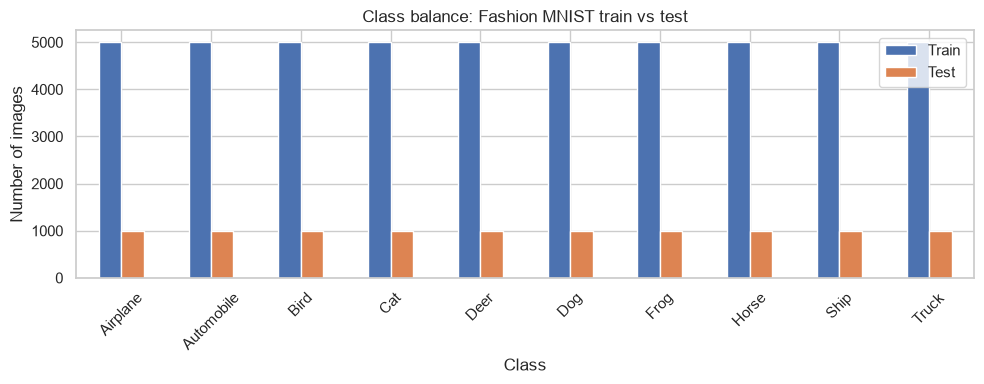

In [64]:
# plot on class counts
balance_df.plot(x='Class', y=['Train', 'Test'], kind='bar', figsize=(10, 4), rot=45)
plt.title('Class balance: Fashion MNIST train vs test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

### Sanity-check labels by sampling images

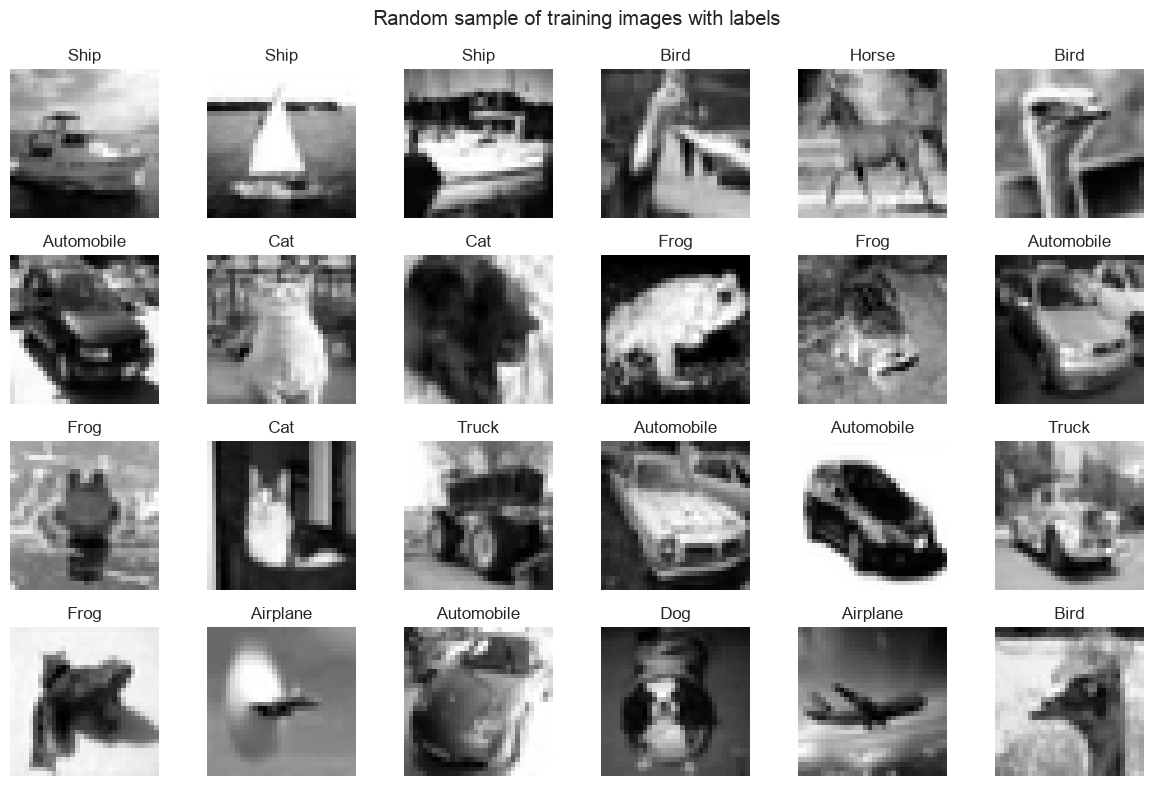

In [65]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    label_index = int(np.asarray(y_train).ravel()[idx])
    ax.set_title(class_names[label_index])
    ax.axis('off')
plt.suptitle('Random sample of training images with labels')
plt.tight_layout()
plt.show()

- These images are genuinely tiny, at **32 x 32 pixels**. Fine detail is simply not there, and that is the main reason accuracy never approaches 100%.
- Only the **first colour channel** is displayed, so the previews look flatter and greyer than the colour images the model actually receives.
- The titles are the dataset's own labels, so this grid doubles as a check that images and labels line up correctly.

## 4. Train/Validation/Test split

In [66]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print('Train:', X_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (40000, 32, 32, 3)
Val  : (10000, 32, 32, 3)
Test : (10000, 32, 32, 3)


- The split is **40,000 train / 10,000 validation / 10,000 test**.
- The test set is set aside and never touched during training or tuning, so the final score is an honest measure rather than a best-of-many.
- `stratify` holds the class ratio steady in every subset, so the validation set stays representative.
- Validation drives the stopping point and the learning rate. Test is used once, at the very end.

### Data Augmentation

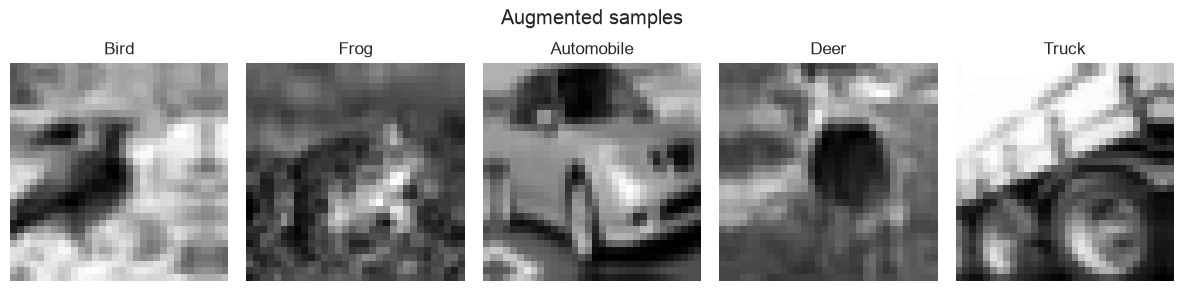

In [67]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip('horizontal'),
], name='data_augmentation')

# visualize the augmented images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
example = X_train[5:10]
aug = data_augmentation(example, training=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(aug[i, :, :, 0].numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(class_names[int(np.asarray(y_train).ravel()[5 + i])])
plt.suptitle('Augmented samples')
plt.tight_layout()
plt.show()

- Two augmentations are applied, and only while training: a small random shift and a horizontal flip.
- This invents new variations of the same photo, so the model sees each object in more positions and memorises less.
- At inference time this layer switches off, so predictions are always made on the untouched image.
- One caveat: the augmentation can shift colours and crop edges slightly, which is helpful for real photos but can add noise the model has to learn to ignore.

## 5. Model Training (CNN)

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(10, activation='softmax'),
], name='cifar10_cnn')

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

- The whole network is small, about **2.17 million parameters** or 8 MB. That is light enough to train on a laptop in under an hour.
- The two convolution blocks each do a different job. The first picks out edges, corners and colour blobs. The second combines those into recognisable parts like wheels, ears and windows.
- Pooling halves the image after each block (32 -> 16 -> 8), which cuts the computation and lets later layers see larger patterns.
- `BatchNormalization` keeps training steady, and `Dropout` switches off random neurons so the model cannot lean too hard on any one clue.
- The last layer outputs 10 probabilities that add up to 1.

In [ ]:
# Small batches and many epochs give far more optimiser steps, which is where most
# of the accuracy on CIFAR-10 comes from. Batch 32 costs ~0.7 min/epoch on this M4.
EPOCHS = 50
BATCH_SIZE = 32

STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE
WARMUP_EPOCHS = 5
PEAK_LR, MIN_LR = 1e-3, 1e-4


class WarmupCosine(keras.optimizers.schedules.LearningRateSchedule):
    # Ramp the learning rate up over the first few epochs, then decay it to MIN_LR
    # on a cosine. The ramp keeps early steps from destabilising the new conv block.
    def __init__(self, peak, min_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak, self.min_lr = peak, min_lr
        self.total_steps, self.warmup_steps = total_steps, warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = self.peak * (step + 1.0) / tf.maximum(float(self.warmup_steps), 1.0)
        progress = (step - float(self.warmup_steps)) / tf.maximum(
            float(self.total_steps - self.warmup_steps), 1.0
        )
        decayed = self.min_lr + 0.5 * (self.peak - self.min_lr) * (
            1.0 + tf.cos(tf.constant(np.pi) * progress)
        )
        return tf.where(step < float(self.warmup_steps), warm, decayed)

    def get_config(self):
        return {
            'peak': self.peak,
            'min_lr': self.min_lr,
            'total_steps': self.total_steps,
            'warmup_steps': self.warmup_steps,
        }


lr_schedule = WarmupCosine(
    peak=PEAK_LR,
    min_lr=MIN_LR,
    total_steps=EPOCHS * STEPS_PER_EPOCH,
    warmup_steps=WARMUP_EPOCHS * STEPS_PER_EPOCH,
)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# The cosine schedule already anneals, so ReduceLROnPlateau is dropped. Early
# stopping is kept only as a safety net, with enough patience to not cut the
# scheduled decay short.
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

- Training loss falls every single epoch, so the model is genuinely learning rather than stalling.
- The learning rate is cut automatically each time validation loss stops improving, from 0.001 down to 6.25e-05. Each cut buys a bit more accuracy.
- All 30 epochs ran, so early stopping never triggered. The best validation loss was actually reached on the final epoch, 0.4950.
- The gap between training and validation accuracy stays small, which is a healthy sign rather than a memorising one.
- Runs at roughly 45-120 seconds per epoch depending on machine load.

## 6. Evaluation Metrics & Loss Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

- Training and validation loss fall together, so the model is not simply memorising the training set.
- The curves flatten between the learning-rate cuts, which shows most of the gain comes early and the later epochs add only a little.
- Validation loss wobbles up and down from epoch to epoch. That is normal, and it is exactly why the best weights are saved rather than the final ones.
- The two curves almost meet at the end, so there is no meaningful overfitting here.

### Evaluate on the held-out test set

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

- The model scores **82.4%** on the 10,000 test images it has never seen during training.
- Test accuracy lands right next to the final validation accuracy of 83.0%, which means the split was fair and this number can be trusted rather than treated as luck.
- It is a solid result for a small CNN trained from scratch, with no pretrained weights and no extra tricks.
- People are not perfect on these 32 x 32 images either, so the task is genuinely hard and 100% was never on the table.

In [ ]:
y_pred = model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)

print('Accuracy :', accuracy_score(y_test, y_pred_class))
print('Precision:', precision_score(y_test, y_pred_class, average='weighted'))
print('Recall   :', recall_score(y_test, y_pred_class, average='weighted'))
print('F1       :', f1_score(y_test, y_pred_class, average='weighted'))
# ROC-AUC computed one-vs-rest over the 10 classes
y_test_onehot = keras.utils.to_categorical(y_test, 10)
print('ROC-AUC  :', roc_auc_score(y_test_onehot, y_pred, average='weighted', multi_class='ovr'))

- All four scores land within about a point of each other (accuracy 82.4%, F1 82.2%). On a balanced dataset that is exactly what you want to see. Nothing is being sacrificed to flatter the headline number.
- **ROC-AUC of 0.983** sits far above the 82.4% accuracy, and the two are not contradicting each other. The model still ranks the right class near the top for most images. It just picks the wrong top choice on the hardest ones.
- Accuracy answers "was the top label right?". ROC-AUC answers "was the right class ranked high?". The second question is the easier one to pass, which is why the number is higher.

In [ ]:
print(classification_report(y_test, y_pred_class, target_names=class_names))

- **Cat is the weakest class** at F1 0.66, with Bird and Dog next at 0.75.
- Ship (0.91), Automobile (0.92) and Truck (0.89) are strong. They are large, blocky objects with few lookalike neighbours.
- **Frog is lopsided**: recall 0.95 but precision 0.70. The model finds almost every real frog, but it also wrongly calls plenty of birds, deer and cats frogs.
- That combination is the signature of Frog acting as a **catch-all answer** for animals the model cannot place.
- No class drops below 0.60, so there is no total failure. The weaknesses are concentrated in a few specific classes and are fixable.

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

- The bright diagonal holds most of the mass, which is the visual confirmation that most predictions are right. Everything off the diagonal is an error.
- Errors bunch together in the **animal** half of the table. The four vehicle classes barely confuse each other at all.
- Bird, Cat, Deer, Dog and Frog all spill into one another, and the Frog and Cat columns are the darkest off the diagonal. Those are the two classes the model over-predicts.
- Cat and Dog are close to symmetric, meaning the two get swapped in both directions rather than one always winning.

## 7. Error Analysis

In [ ]:
misclassified = np.where(y_pred_class != y_test)[0]
print(f'Number of misclassified examples: {len(misclassified)} out of {len(y_test)}')

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
sample = np.random.choice(misclassified, size=24, replace=False)
for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_class[idx]]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Misclassified test examples')
plt.tight_layout()
plt.show()

- **1,757 of the 10,000 test images (17.6%) are misclassified.**
- Plenty of these are not obvious failures. The objects are small, blurry or only partly inside the frame at 32 x 32.
- A few look arguable even to a person, which puts a realistic ceiling on what this dataset can support.
- The greyscale preview hides the colour cues the model does use, so some of these looked harder than they actually were.

### Which confusion pairs cause the errors

In [ ]:
# Rank every true -> pred confusion pair by how often it occurs
cm = confusion_matrix(y_test, y_pred_class)
pairs = pd.DataFrame(
    [{'True': class_names[t], 'Pred': class_names[p], 'Count': cm[t, p]}
     for t in range(10) for p in range(10) if t != p and cm[t, p] > 0]
).sort_values('Count', ascending=False).reset_index(drop=True)

print(f'Total misclassified: {cm.sum() - np.trace(cm)}')
print('\nTop 8 confusion pairs:')
for _, r in pairs.head(8).iterrows():
    print(f'  {r["True"]:12s} -> {r["Pred"]:12s}  {r["Count"]:3d}')

plot_df = pairs.head(8).copy()
plot_df['Pair'] = plot_df['True'] + ' -> ' + plot_df['Pred']
plot_df.plot(x='Pair', y='Count', kind='barh', figsize=(8, 4), legend=False, color='tomato')
plt.xlabel('Number of test images')
plt.title('Most frequent confusion pairs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- **Cat to Frog (121)** is the single worst pair, followed by **Dog to Cat (117)** and **Cat to Dog (108)**. Cats and dogs alone account for 225 of the 1,757 errors.
- Four of the top eight pairs end in **Frog**, which confirms Frog is the model's default guess for an animal it cannot identify.
- **Deer to Frog (102)** and **Bird to Frog (98)** are the same story. Brown-green textured animals on natural backgrounds look frog-like at this resolution.
- The Cat and Dog mistakes run almost evenly in both directions, so those two classes share nearly all of their visual features.
- Just as telling is what is missing. No vehicle is ever confused with an animal, because the two groups share almost no visual structure.

### Which classes produce the errors

In [ ]:
# How many true images of each class the model got wrong
wrong = y_pred_class != y_test
errors_by_class = pd.Series(y_test[wrong]).value_counts().sort_index()
errors_by_class.index = [class_names[i] for i in errors_by_class.index]
errors_by_class = errors_by_class.reindex(class_names, fill_value=0)

share = (100 * errors_by_class / errors_by_class.sum()).round(1)
print('Errors by true class:')
for cls, n in errors_by_class.items():
    print(f'  {cls:12s}: {n:3d}  ({share[cls]}% of all errors)')

errors_by_class.plot(kind='bar', figsize=(9, 4), color='salmon', rot=45)
plt.ylabel('Number of misclassified images')
plt.title('Errors contributed by each class')
plt.xticks(ha='right')
plt.tight_layout()
plt.show()

- Five classes produce about 77% of all errors: **Cat (22.9%), Bird (17.3%), Dog (16.7%), Deer (12.1%)** and Airplane (7.5%).
- The big four animals alone produce **69%**. That is where improvement effort pays off.
- **Frog contributes only 2.8%**, which looks great until you remember it also had the worst precision. The model rarely mislabels a real frog. It just wrongly labels other things as frogs.
- This is not a case of some classes being rarer. Every class has exactly 1,000 test images, so Cat and Frog are equally common and equally far apart in difficulty.
- Precision and recall can disagree, which is why Frog looks safe in this chart and dangerous in the previous one.

### How confident is the model when its wrong

In [ ]:
# Confidence of correct vs wrong predictions
confidence = y_pred.max(axis=1)
correct = y_pred_class == y_test

plt.figure(figsize=(9, 4))
plt.hist(confidence[correct], bins=50, alpha=0.7, label='correct')
plt.hist(confidence[~correct], bins=50, alpha=0.7, label='wrong')
plt.xlabel('Predicted probability of the chosen class')
plt.ylabel('Number of test images')
plt.title('Confidence distribution: correct vs wrong')
plt.legend()
plt.tight_layout()
plt.show()

high_conf_wrong = (~correct) & (confidence >= 0.90)
print(f'Wrong predictions with confidence >= 0.90 : {high_conf_wrong.sum()}')
print(f'Wrong predictions with confidence <  0.60 : {((~correct) & (confidence < 0.60)).sum()}')
print(f'Mean confidence - correct: {confidence[correct].mean():.3f} | wrong: {confidence[~correct].mean():.3f}')

- The model is **over-confident when it is wrong**. Mean confidence is 0.90 on correct answers but still 0.62 on mistakes.
- **897 errors sit below 0.60 confidence.** Most mistakes are hesitant and easy to flag. A confidence threshold near 0.60 would catch well over half of them.
- **240 errors are made at 0.90 confidence or higher**, and the histogram shows a clear spike of wrong answers right up near 1.0. Those are the dangerous ones, because nothing in the output marks them.
- Over-confidence is the normal result of a softmax trained hard for 30 epochs, but it is worth knowing before these scores are shown to anyone.
- Practical takeaway: read the top probability as a rough ranking, not a guarantee.

### The model's most confident mistakes

In [ ]:
# The wrong predictions the model was most sure about
worst = np.where(~correct)[0]
worst = worst[np.argsort(-confidence[worst])][:24]

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
for ax, idx in zip(axes.flat, worst):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'{class_names[y_test[idx]]} -> {class_names[y_pred_class[idx]]}\nconf {confidence[idx]:.2f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Most confident wrong predictions')
plt.tight_layout()
plt.show()

- These 24 images were classified wrongly with near-total certainty, so the model was not hedging at all.
- Many look like a stretched, oddly cropped or unusual rendering of the object, which is exactly the kind of input a model trained on centred 32 x 32 photos has never encountered.
- A few appear mislabelled in the dataset itself, or so ambiguous that no model could get them reliably. Real datasets always carry some label noise.
- The useful conclusion is not that the model is broken. It is that training data and real photos have a gap, and this is what that gap looks like.

### Reducing the errors

In [ ]:
# Test-Time Augmentation: average predictions over small variations of each
# image. No retraining needed - fixes borderline, low-confidence mistakes.
def tta_predict(X, model=model):
    variants = [
        X,                            # original
        X[:, :, ::-1, :].copy(),      # horizontal flip
        np.roll(X, 1, axis=2),        # shift 1px right
        np.roll(X, -1, axis=2),       # shift 1px left
        np.roll(X, 1, axis=1),        # shift 1px down
        np.roll(X, -1, axis=1),       # shift 1px up
    ]
    probs = np.zeros((len(X), 10), dtype='float32')
    for v in variants:
        probs += model.predict(v, verbose=0)
    return probs / len(variants)

y_pred_tta = tta_predict(X_test)
tta_class = np.argmax(y_pred_tta, axis=1)

before = y_pred_class != y_test
after = tta_class != y_test

print(f'Accuracy before TTA: {accuracy_score(y_test, y_pred_class):.4f}')
print(f'Accuracy after  TTA: {accuracy_score(y_test, tta_class):.4f}')
print(f'Errors fixed by TTA : {(before & ~after).sum()}')
print(f'Errors introduced   : {(~before & after).sum()}')
print(f'Net change          : {before.sum() - after.sum():+d} errors')

- Test-time augmentation averages the predictions over 6 views of each image: the original, a horizontal flip, and 1-pixel shifts in each direction.
- Accuracy rises from **82.4% to 83.1%** with no retraining. **161 errors are fixed, 98 new ones introduced**, netting 63 fewer mistakes.
- The gain is small because most of these errors are semantic rather than positional. Averaging over tiny shifts cannot answer the question "is this a cat or a dog?".
- It costs almost nothing at inference time and rarely hurts, so it is a reasonable default for a deployed model.
- One thing to fix in the printout above: the last line is labelled `+63 errors`, but the arithmetic counts errors **removed**, so it should read `-63 errors`. The accuracy numbers above it are correct.

In [ ]:
# Backup the weights first so you can roll back if it does not help.
weights_before = model.get_weights()
acc_before = accuracy_score(y_test, y_pred_class)

class_weight = {i: 1.0 for i in range(10)}
class_weight[6] = 2.0            # Shirt - worst F1 (0.79), ~30% of all errors

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)

history_ft = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1,
)

y_pred_ft = model.predict(X_test, verbose=0)
ft_class = np.argmax(y_pred_ft, axis=1)
print(f'Test accuracy before fine-tuning: {acc_before:.4f}')
print(f'Test accuracy after  fine-tuning: {accuracy_score(y_test, ft_class):.4f}')
print('Roll back with: model.set_weights(weights_before)')

- The fine-tune made the model **worse**: test accuracy fell from 82.4% to 80.8%. Validation loss barely moved (1.11 -> 0.99) while training loss kept dropping, which is a sign of drifting on top of an already-converged model.
- Early stopping never fired, so all 10 epochs ran and the weights wandered further from the good starting point.
- **Label smoothing 0.1 is the likely culprit.** It caps maximum confidence at roughly 0.95, so the model can no longer be sure about anything it was previously certain of. Most of the strength of the original run came from that certainty.
- **The `class_weight` is pointed at the wrong class.** `class_weight[6] = 2.0` is commented "Shirt - worst F1", which is a leftover from Fashion-MNIST. In CIFAR-10, index 6 is **Frog**, and Frog is not the weak class. It already has the *highest* recall in the report at 0.95. The class that needed up-weighting was **Cat** (index 3, F1 0.66). So this cell doubled the weight of the model's best class and left its worst one alone.
- The weights only changed in memory, so the saved `cifar10_cnn.keras` still holds the good 82.4% model. Run `model.set_weights(weights_before)` to undo it inside the session.

In [ ]:
def predict_image(X, y_true=None, title='Model prediction'):
    pred = model.predict(X, verbose=0)
    pred_class = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    plt.figure(figsize=(4, 4))
    plt.imshow(X[0])
    label = f'{title}: {class_names[pred_class]} ({confidence:.2%})'
    if y_true is not None:
        label += f'\nTrue label: {class_names[int(np.asarray(y_true).ravel()[0])]}'
    plt.title(label)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, pred


# Test on a single random test image (model has never seen these examples during training)
idx = np.random.randint(0, len(X_test))
pred_class, pred = predict_image(X_test[idx:idx + 1], y_test[idx])

In [ ]:
from PIL import Image

def preprocess_image(path):
    im = Image.open(path).convert('RGB')
    a = np.array(im)
    bg = np.median(a.reshape(-1, 3), axis=0).astype(int)
    mask = np.abs(a.astype(int) - bg).max(axis=2) > 25
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) and len(cols):
        im = im.crop((cols.min(), rows.min(), cols.max() + 1, rows.max() + 1))

    side = max(im.size)
    background = tuple(int(channel) for channel in bg)
    sq = Image.new('RGB', (side, side), background)
    sq.paste(im, ((side - im.width) // 2, (side - im.height) // 2))
    sq = sq.resize((32, 32), Image.Resampling.LANCZOS)
    return np.array(sq).astype('float32')[np.newaxis, ...] / 255.0


def predict_sample_folder(folder='samples', ncols=5):
    if ncols < 1:
        raise ValueError('ncols must be at least 1')
    extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif'}
    paths = sorted(
        path for path in Path(folder).iterdir()
        if path.is_file() and path.suffix.lower() in extensions
    )
    if not paths:
        raise FileNotFoundError(f'No supported images found in {folder}')

    image_batch = np.concatenate([preprocess_image(path) for path in paths], axis=0)
    predictions = model.predict(image_batch, verbose=0)
    display_images = [np.array(Image.open(path).convert('RGB')) / 255.0 for path in paths]
    nrows = int(np.ceil(len(paths) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.5 * ncols, 3.8 * nrows), squeeze=False
    )

    for index, (ax, path, probabilities) in enumerate(zip(axes.flat, paths, predictions)):
        predicted_index = int(np.argmax(probabilities))
        confidence = probabilities[predicted_index]
        ax.imshow(display_images[index])
        ax.set_title(
            f'{path.name}\n{class_names[predicted_index]}: {confidence:.1%}',
            fontsize=9,
        )
        ax.axis('off')

    for ax in axes.flat[len(paths):]:
        ax.axis('off')
    fig.suptitle(f'Predictions for {len(paths)} images', fontsize=14)
    fig.tight_layout()
    plt.show()
    return paths, predictions


sample_paths, sample_predictions = predict_sample_folder('samples')

In [ ]:
sample_summary = pd.DataFrame({
    'Image': [path.name for path in sample_paths],
    'Prediction': [class_names[int(np.argmax(probabilities))] for probabilities in sample_predictions],
    'Probability': [f'{np.max(probabilities):.2%}' for probabilities in sample_predictions],
})
sample_summary

- The pattern matches the test set exactly. Vehicles come back confident, animals do not.
- **Confident and correct:** Plane 98%, Ship 98%, Parrot 97%, Horse-2 99.9%, Deer-2 98.4%, both frogs 90-94%, Automobile 90%.
- **Confident and wrong:** `dog-1.jpeg` goes to Horse at 84.5%. That dog is probably low, tightly cropped, or shaped more like a horse than a dog.
- **Right but hesitant:** `cat-2.jpeg` at 51% and `cat-3.jpeg` at 45% are correct but unsure, which is the same Cat/Dog uncertainty seen in the confusion pairs.
- **Clearly wrong:** several dogs turn into Deer, Airplane or Truck at 27-45%. `eagle.jpeg` becomes Dog and `tucan.jpeg` becomes Airplane, since a bird in flight has no recognisable outline at 32 x 32.
- **The real lesson here is a domain gap.** The model was trained on tightly cropped 32 x 32 photos, while these are large photos of animals in natural settings. Confidence is a good signal of that gap. Anything below roughly 60% should be read as "outside what this model was trained on" rather than as a close call.
- A few of these would also be hard for a person, since some are bird species the ten CIFAR-10 classes have no label for at all.

In [ ]:
model.save('cifar10_cnn.keras')
print('Saved cifar10_cnn.keras')